# Flow Matching \/ Rectified Flow for MRI Artifact Reduction
This notebook implements a Continuous Normalizing Flow (Rectified Flow) for conditional image generation. 
It learns a vector field that transports standard Gaussian noise to the Clean MRI distribution, conditioned on the Artifact MRI.

In [6]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import skimage.metrics as metrics
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


## 1. Dataset Loader


In [7]:
class KMARDataset(Dataset):
    def __init__(self, root_dir, slice_range=(10, 20), subset_vols=None):
        self.noisy_dir = os.path.join(root_dir, 'ArtifactData')
        self.clean_dir = os.path.join(root_dir, 'GroundTruthData')
        self.slice_range = slice_range
        
        noisy_files = set(os.listdir(self.noisy_dir))
        clean_files = set(os.listdir(self.clean_dir))
        self.files = [f for f in noisy_files.intersection(clean_files) if f.endswith('.nii.gz')]
        self.files.sort()
        if subset_vols is not None:
            self.files = self.files[:subset_vols]
        
        self.valid_slices = []
        for f in self.files:
            for i in range(self.slice_range[0], self.slice_range[1]):
                self.valid_slices.append((f, i))
        print(f'Total 2D slices extracted: {len(self.valid_slices)}')

    def __len__(self):
        return len(self.valid_slices)

    def preprocess(self, x):
        x = x.astype(np.float32)
        x_min, x_max = x.min(), x.max()
        if x_max > x_min:
            x = (x - x_min) / (x_max - x_min)
        x = torch.tensor(x).unsqueeze(0)
        x = F.interpolate(x.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False).squeeze(0)
        x = x * 2.0 - 1.0
        return x

    def __getitem__(self, idx):
        fname, slice_idx = self.valid_slices[idx]
        noisy_path = os.path.join(self.noisy_dir, fname)
        clean_path = os.path.join(self.clean_dir, fname)
        
        noisy_vol = nib.load(noisy_path).get_fdata()
        clean_vol = nib.load(clean_path).get_fdata()
        
        s_idx = min(slice_idx, noisy_vol.shape[2]-1)
        
        noisy_slice = noisy_vol[:, :, s_idx]
        clean_slice = clean_vol[:, :, s_idx]
        
        return self.preprocess(noisy_slice), self.preprocess(clean_slice)

In [8]:
root_path = '/home/kartik/Desktop/shalini/KMAR-50K'
dataset = KMARDataset(root_path, slice_range=(10, 16), subset_vols=100)
loader = DataLoader(dataset, batch_size=8, shuffle=True, drop_last=True)

Total 2D slices extracted: 600


## 2. Conditional U-Net for Vector Field Regression
The U-Net architecture maps $(x_t, cond, t)$ to the vector field $v_\theta$.

In [9]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=time.device) * -embeddings)
        # time is in [0, 1]. Map it to a larger scale for the positional embeddings.
        embeddings = (time[:, None] * 1000.0).float() * embeddings[None, :]
        return torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)

class Block(nn.Module):
    def __init__(self, in_c, out_c, time_emb_dim=None):
        super().__init__()
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_c)) if time_emb_dim else None
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.norm1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.norm2 = nn.BatchNorm2d(out_c)
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        h = self.act(self.norm1(self.conv1(x)))
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb[:, :, None, None]
        return self.act(self.norm2(self.conv2(h)))

class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        time_dim = 128
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim)
        )
        
        self.inc = nn.Conv2d(2, 64, kernel_size=1)
        
        self.down1 = Block(64, 128, time_dim)
        self.down2 = Block(128, 256, time_dim)
        self.down3 = Block(256, 512, time_dim)
        
        self.pool = nn.MaxPool2d(2)
        
        self.bot1 = Block(512, 512, time_dim)
        self.bot2 = Block(512, 512, time_dim)
        
        self.up1 = nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2)
        self.upb1 = Block(512 + 512, 256, time_dim)
        
        self.up2 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.upb2 = Block(256 + 256, 128, time_dim)
        
        self.up3 = nn.ConvTranspose2d(128, 128, kernel_size=2, stride=2)
        self.upb3 = Block(128 + 128, 64, time_dim)
        
        self.outc = nn.Conv2d(64, 1, kernel_size=1)
        
    def forward(self, x, cond, t):
        t = self.time_mlp(t)
        x = torch.cat([x, cond], dim=1)
        x = self.inc(x)
        
        x1 = self.down1(x, t)
        p1 = self.pool(x1)
        
        x2 = self.down2(p1, t)
        p2 = self.pool(x2)
        
        x3 = self.down3(p2, t)
        p3 = self.pool(x3)
        
        b = self.bot1(p3, t)
        b = self.bot2(b, t)
        
        u1 = self.up1(b)
        u1 = self.upb1(torch.cat([x3, u1], dim=1), t)
        
        u2 = self.up2(u1)
        u2 = self.upb2(torch.cat([x2, u2], dim=1), t)
        
        u3 = self.up3(u2)
        u3 = self.upb3(torch.cat([x1, u3], dim=1), t)
        
        return self.outc(u3)

## 3. Training Loop (Vector Field Regression)


In [10]:
model = ConditionalUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

epochs = 10
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (noisy, clean) in enumerate(loader):
        cond = noisy.to(device)
        x1 = clean.to(device)  # Target data
        x0 = torch.randn_like(x1)  # Gaussian noise
        
        # Sample t uniformly from [0, 1]
        t = torch.rand(x1.shape[0], device=device)
        
        # Interpolate
        t_expanded = t[:, None, None, None]
        xt = t_expanded * x1 + (1 - t_expanded) * x0
        
        # Target vector field
        target_v = x1 - x0
        
        # Predicted vector field
        pred_v = model(xt, cond=cond, t=t)
        
        loss = criterion(pred_v, target_v)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}')


Epoch 1/10 | Loss: 0.6097
Epoch 2/10 | Loss: 0.3246
Epoch 3/10 | Loss: 0.2287
Epoch 4/10 | Loss: 0.1764
Epoch 5/10 | Loss: 0.1675
Epoch 6/10 | Loss: 0.1462
Epoch 7/10 | Loss: 0.1438
Epoch 8/10 | Loss: 0.1328
Epoch 9/10 | Loss: 0.1220
Epoch 10/10 | Loss: 0.1173


## 4. Sampling using Euler ODE Solver


In [11]:
@torch.no_grad()
def euler_sample(cond, steps=20):
    model.eval()
    b = cond.shape[0]
    x = torch.randn_like(cond)
    
    dt = 1.0 / steps
    
    for i in range(steps):
        t_val = i * dt
        t_tensor = torch.full((b,), t_val, device=device)
        
        v = model(x, cond, t_tensor)
        x = x + v * dt
        
    return x

cond_batch, clean_batch = next(iter(loader))
cond_batch, clean_batch = cond_batch.to(device), clean_batch.to(device)
sampled_batch = euler_sample(cond_batch, steps=20)


In [12]:
def evaluate_batch(clean, fake):
    clean = (clean + 1) / 2.0
    fake = (fake + 1) / 2.0
    clean_np = clean.clamp(0,1).cpu().numpy()
    fake_np = fake.clamp(0,1).cpu().numpy()
    
    psnr_vals, ssim_vals = [], []
    for i in range(clean.size(0)):
        p = metrics.peak_signal_noise_ratio(clean_np[i,0], fake_np[i,0], data_range=1.0)
        s = metrics.structural_similarity(clean_np[i,0], fake_np[i,0], data_range=1.0)
        psnr_vals.append(p)
        ssim_vals.append(s)
    return np.mean(psnr_vals), np.mean(ssim_vals)

psnr_val, ssim_val = evaluate_batch(clean_batch, sampled_batch)
print(f'Test PSNR: {psnr_val:.2f} | Test SSIM: {ssim_val:.4f}')

Test PSNR: 19.80 | Test SSIM: 0.3917


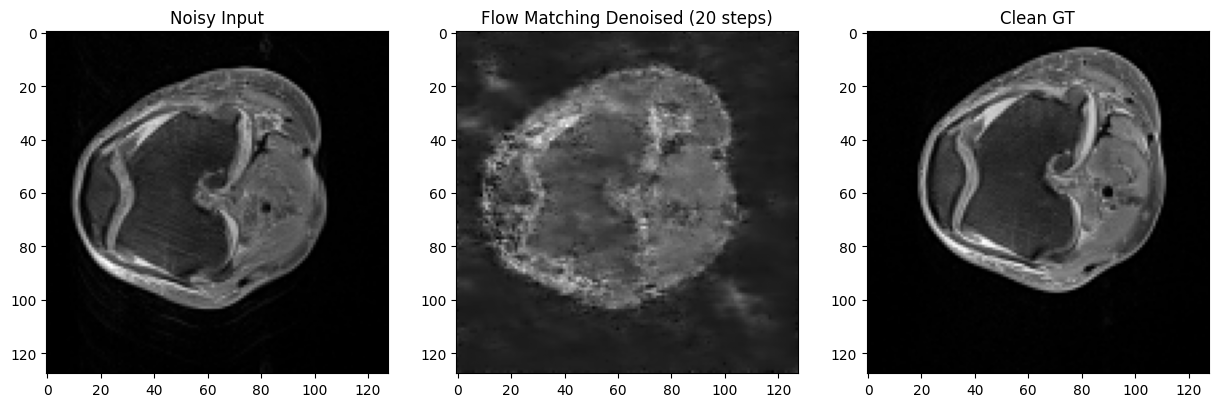

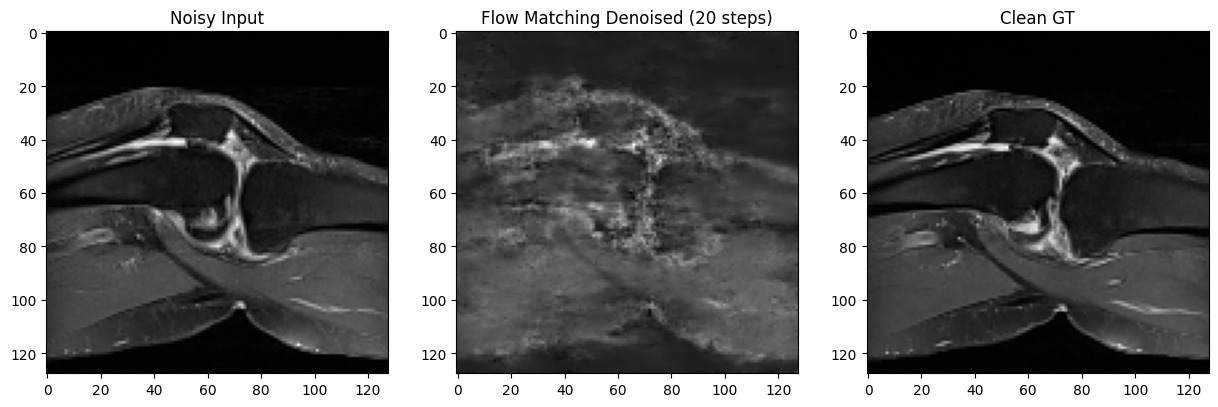

In [13]:
for i in range(2):
    plt.figure(figsize=(15, 5))
    plt.subplot(1,3,1), plt.imshow(cond_batch[i][0].cpu().numpy(), cmap='gray'), plt.title('Noisy Input')
    plt.subplot(1,3,2), plt.imshow(sampled_batch[i][0].cpu().numpy(), cmap='gray'), plt.title('Flow Matching Denoised (20 steps)')
    plt.subplot(1,3,3), plt.imshow(clean_batch[i][0].cpu().numpy(), cmap='gray'), plt.title('Clean GT')
    plt.show()